---
title: "The shrinking core, and when its three textbook limits are safe to use"
description: "Yagi and Kunii's one equation contains all three classical regimes. Reading it off the 1955 page and integrating the moving boundary independently gives the same thing to machine precision — and then says where the simplifications may be used."
categories: [sec:B, struct:S12, tier:T0, data:tier6, phase:gas-solid]
date: 2026-07-29
---

# The shrinking core, and when its three textbook limits are safe to use

**Catalog ID:** `B3.1` · **Structures:** `S12` (moving boundary) · **Tier:** T0

A lump of carbon burning in air develops an ash shell. Oxygen must cross a
boundary film, diffuse through that shell, and react at the surface of the
shrinking unburned core. Three resistances in series, and a boundary that moves
as the core is consumed.

Every textbook gives three limiting conversion–time laws for this problem — one
per controlling resistance. **Yagi and Kunii's 1955 paper gives the single
equation all three come from**, and almost nobody quotes it.

## Background

The shrinking-core picture applies when the solid is **non-porous**: gas cannot
penetrate the unreacted material, so reaction is confined to a sharp interface at
radius $r$ inside a particle of radius $R$. Yagi and Kunii state the assumption
directly — an ash layer "remains around the unburned core of the particle and
prevents the diffusion of gas".

The three resistances, and the three limiting laws they produce, are standard:

| controlling step | conversion–time law |
|---|---|
| gas film | $\theta/\theta_B = X$ |
| ash-layer diffusion | $\theta/\theta_B = 1 - 3(1-X)^{2/3} + 2(1-X)$ |
| surface reaction | $\theta/\theta_B = 1 - (1-X)^{1/3}$ |

with $X = 1 - (r/R)^3$ the conversion. What is *not* standard is that these are
three corners of one expression, and that the paper prints it.

This page reproduces that expression, checks it two independent ways, and then
answers the question the three-way split raises but never settles: **given a real
particle, which law may you actually use, and how wrong is it?**

## The published model

Two equations, read off 600 dpi renders of the printed page. The text layer of
this scan is badly mangled — it renders $\theta_B$ as `0B`, $\omega$ as `~`, and
Eq. 6's numerator as a run of broken glyphs — so nothing here comes from OCR.

**Eq. 5**, the three resistances in series:

$$
\frac{1}{\bar k_1} = \frac{1}{k_{c1}} + \frac{1}{k_{d1}} + \frac{1}{3k_{f1}},
\qquad k_{d1} = \frac{12\,\mathbb{D}_{vs}}{D_p}
$$

Note the **factor 3 on the film term** and the **12** in $k_{d1}$. Both are easy
to lose, and both are checkable — see the validation section.

**Eq. 6**, the position of the interface against time:

$$
\frac{\theta}{\theta_B} = 1 - \frac{\gamma\,(r/R) + 3\omega\gamma\,(r/R)^2
+ \omega(1-2\gamma)\,(r/R)^3}{\omega + \omega\gamma + \gamma}
$$

$$
\omega = \frac{k_{c1}}{k_{d1}},\qquad
\gamma = \frac{3k_{f1}}{k_{d1}},\qquad
\theta_B = \frac{D_p}{2\alpha\bar k_1 C_1}
$$

$\theta_B$ is the time for complete combustion. Two dimensionless groups
$(\omega,\gamma)$ therefore fix the entire conversion history — which is why this
page can be complete without a single physical property.

## Parameters and assumptions

**Assumptions:** non-porous solid, so a sharp interface; quasi-steady gas
diffusion in the ash shell; constant particle size (ash retained, no shrinkage of
the outer radius); isothermal; first-order in the gas.

**What this page deliberately does not compute.** The paper obtains $k_{c1}$ in
cm/s "by changing the unit of the specific combustion rate $K_c$" in Parker and
Hottel's correlation,

$$10^3 K_c = \frac{9.55\times10^{9}}{\sqrt{T}}\,P_o\,\exp(-44{,}000/RT),$$

but **the unit conversion itself is not printed**. Without it $k_{c1}$ cannot be
recovered, so no absolute burnout time is quoted anywhere below, and the paper's
Figure 6 is not reproduced. Guessing the conversion would put invented numbers on
the page. Everything here is expressed in $\omega$, $\gamma$ and $\theta/\theta_B$
instead, which is exactly what Eq. 6 needs and costs nothing — the physics of the
regime question is entirely dimensionless.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from pymrm import construct_grad, construct_div
from gallery_utils import report_agreement

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

**There is none, and there should not be.** This page is provenance tier 6: the
content is an analytic relation and its limits, and the checks below are
mathematical rather than experimental. The paper's own measurements are of
fluidised-bed elutriation and particle size distributions, which belong to a
different model entirely.

Recording that plainly matters more than it looks. The gallery's rule is never to
present a re-simulation as data; the honest alternative is to say that a page has
no experimental content and to make its validation carry the weight instead.

## PyMRM implementation

Three pieces. The first is the paper's equation, the second is an independent
route to it, and the third is the only part that needs a solver.

**Eq. 6 directly.** Two lines of algebra.

**The moving boundary, integrated from the resistances.** If Eq. 5 is right, then
the instantaneous molar flow to a core at radius $r_c$ is

$$
W = \frac{4\pi C_1}{\dfrac{1}{k_c r_c^2}
+ \dfrac{1}{\mathbb{D}}\left(\dfrac{1}{r_c}-\dfrac{1}{R}\right)
+ \dfrac{1}{k_f R^2}},
$$

and equating solid consumption to it gives $\theta(r_c)$ by quadrature. That
route never looks at Eq. 6, so agreement between the two is a real check on
having read the printed equation correctly.

**The ash shell itself, with pymrm.** The quasi-steady gas profile in
$r_c \le r \le R$ is a spherical diffusion problem with a Robin condition at each
face — reaction at the inner one, film transfer at the outer:

$$
\nabla\!\cdot\!\left(-\mathbb{D}\nabla C\right) = 0,\qquad
\left.\mathbb{D}\frac{\partial C}{\partial n} + k_c C\right|_{r_c}\!\!= 0,\qquad
\left.\mathbb{D}\frac{\partial C}{\partial n} + k_f C\right|_{R}\!\!= k_f C_1 .
$$

Both use the **outward** normal, which points inward at the core face — that is
why the reaction condition has $d = 0$ and the same sign structure as the film
one. `construct_div(..., nu=2)` supplies the spherical geometry.

In [3]:
def eq6(x, omega, gamma):
    """Yagi & Kunii eq. (6): theta/theta_B against x = r/R."""
    x = np.asarray(x, float)
    num = gamma * x + 3.0 * omega * gamma * x**2 + omega * (1.0 - 2.0 * gamma) * x**3
    return 1.0 - num / (omega + omega * gamma + gamma)


def theta_from_resistances(x, kc, kf, D, R):
    """Same quantity, reached by integrating the moving boundary instead."""
    x = np.asarray(x, float)
    num = (1 - x) / kc + (R / D) * ((1 - x**2) / 2 - (1 - x**3) / 3) + (1 - x**3) / (3 * kf)
    den = 1 / kc + R / (6 * D) + 1 / (3 * kf)
    return num / den


def groups(kc, kf, D, R):
    """(omega, gamma) from physical coefficients, using eq. 5's k_d1 = 12 D / D_p."""
    kd = 6.0 * D / R                      # = 12 D / (2R)
    return kc / kd, 3.0 * kf / kd


def shell_profile(rc, R, D, kc, kf, C1=1.0, n=400):
    """Quasi-steady gas concentration through the ash shell, by pymrm."""
    r_f = np.linspace(rc, R, n + 1)
    r_c = 0.5 * (r_f[:-1] + r_f[1:])
    shape = (n, 1)
    bc = ({"a": D, "b": kc, "d": 0.0},          # inner face: reaction sink
          {"a": D, "b": kf, "d": kf * C1})      # outer face: film transfer
    grad, grad_bc = construct_grad(shape, r_f, r_c, bc)
    div = construct_div(shape, r_f, nu=2)
    lhs = div @ (-D * grad)
    rhs = -(div @ (-D * grad_bc)).toarray().ravel()
    return r_c.ravel(), spsolve(lhs.tocsc(), rhs)


def shell_flow(rc, R, D, kc, kf, C1=1.0, n=400):
    """Molar flow reaching the core, from the pymrm profile."""
    r, C = shell_profile(rc, R, D, kc, kf, C1, n)
    dCdr = (C[1] - C[0]) / (r[1] - r[0])
    rm = 0.5 * (r[0] + r[1])
    return 4.0 * np.pi * rm**2 * D * dCdr


def flow_analytic(rc, R, D, kc, kf, C1=1.0):
    return 4.0 * np.pi * C1 / (1/(kc*rc**2) + (1/rc - 1/R)/D + 1/(kf*R**2))


REGIMES = {
    "film":     lambda X: X,
    "ash":      lambda X: 1 - 3*(1-X)**(2/3) + 2*(1-X),
    "reaction": lambda X: 1 - (1-X)**(1/3),
}
print("eq. (6) implemented; three classical laws available for comparison")

eq. (6) implemented; three classical laws available for comparison


## Results

Eq. 6 against its own three corners, and against the independent integration.

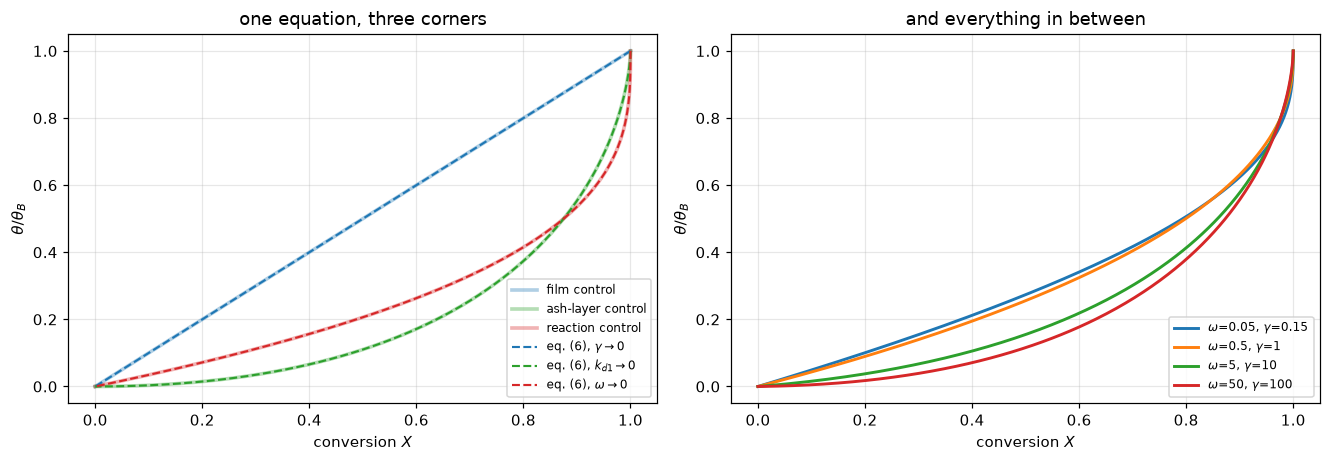

   eq. (6) -> film      control:  max deviation 8.21e-10
   eq. (6) -> ash       control:  max deviation 2.35e-08
   eq. (6) -> reaction  control:  max deviation 3.85e-10


In [4]:
x = np.linspace(0, 1, 400)
X = 1 - x**3
fig, ax = plt.subplots(1, 2, figsize=(12.2, 4.3))

for lab, f, col in (("film control", REGIMES["film"], "tab:blue"),
                    ("ash-layer control", REGIMES["ash"], "tab:green"),
                    ("reaction control", REGIMES["reaction"], "tab:red")):
    ax[0].plot(X, f(X), lw=2.4, color=col, alpha=0.35, label=lab)
BIG = 1e7
ax[0].plot(X, eq6(x, 1.0, 1e-9), "--", lw=1.4, color="tab:blue",
           label=r"eq. (6), $\gamma\to0$")
ax[0].plot(X, eq6(x, BIG, 3*BIG), "--", lw=1.4, color="tab:green",
           label=r"eq. (6), $k_{d1}\to0$")
ax[0].plot(X, eq6(x, 1e-9, 1.0), "--", lw=1.4, color="tab:red",
           label=r"eq. (6), $\omega\to0$")
ax[0].set(xlabel="conversion $X$", ylabel=r"$\theta/\theta_B$",
          title="one equation, three corners")
ax[0].legend(fontsize=8, loc="lower right")

for om, ga, lab in ((0.05, 0.15, r"$\omega$=0.05, $\gamma$=0.15"),
                    (0.5, 1.0, r"$\omega$=0.5, $\gamma$=1"),
                    (5.0, 10.0, r"$\omega$=5, $\gamma$=10"),
                    (50.0, 100.0, r"$\omega$=50, $\gamma$=100")):
    ax[1].plot(X, eq6(x, om, ga), lw=1.9, label=lab)
ax[1].set(xlabel="conversion $X$", ylabel=r"$\theta/\theta_B$",
          title="and everything in between")
ax[1].legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

for lab, (om, ga) in (("film", (1.0, 1e-9)), ("ash", (BIG, 3*BIG)),
                      ("reaction", (1e-9, 1.0))):
    err = np.abs(eq6(x, om, ga) - REGIMES[lab](X)).max()
    print(f"   eq. (6) -> {lab:9s} control:  max deviation {err:.2e}")

## Validation

Four checks, and the first two are the ones that establish the printed equations
were read correctly.

In [5]:
print("1. Eq. 6 is exact at both endpoints, for any (omega, gamma)")
for om, ga in [(0.3, 2.0), (5.0, 0.1), (1e3, 1e3), (1e-6, 1e6)]:
    print(f"   omega={om:9.1e} gamma={ga:9.1e}   theta(x=1) = {eq6(1.0,om,ga):+.2e}"
          f"   theta(x=0) = {eq6(0.0,om,ga):.10f}")
print("   Nothing enforces this: the numerator at x=1 must collapse to the")
print("   denominator term by term, which it does only for the printed coefficients.\n")

print("2. Eq. 6 IS the integral of eq. 5's three resistances")
R_p, D_g = 0.05, 1e-4
worst = 0.0
print(f"   {'kc':>8}{'kf':>8}{'omega':>10}{'gamma':>10}{'max |diff|':>13}")
for kc, kf in [(1e-2,1e-2),(1e-1,1e-3),(1e-3,1e-1),(1.0,1.0),(1e-4,1e2),(1e2,1e-4)]:
    om, ga = groups(kc, kf, D_g, R_p)
    d = np.abs(eq6(x, om, ga) - theta_from_resistances(x, kc, kf, D_g, R_p)).max()
    worst = max(worst, d)
    print(f"   {kc:8.0e}{kf:8.0e}{om:10.3f}{ga:10.3f}{d:13.2e}")
print(f"   worst {worst:.1e} over six decades of resistance ratio.")
print("   The integration route never looks at eq. 6, and reproduces both the")
print("   factor 3 on the film term and the 12 in k_d1 = 12 D/D_p independently.\n")

print("3. The pymrm shell solve reproduces the analytic series resistance")
print(f"   {'rc/R':>6}{'kc':>8}{'kf':>8}{'W pymrm':>13}{'W analytic':>13}{'rel err':>11}")
errs = []
for xf in (0.9, 0.6, 0.3):
    for kc, kf in ((1e-2, 1e-2), (1.0, 1e-3)):
        rc = xf * R_p
        W = shell_flow(rc, R_p, D_g, kc, kf)
        Wa = flow_analytic(rc, R_p, D_g, kc, kf)
        errs.append(abs(W - Wa) / Wa)
        print(f"   {xf:6.1f}{kc:8.0e}{kf:8.0e}{W:13.5e}{Wa:13.5e}{errs[-1]:11.2e}")
print(f"   worst {max(errs):.1e}\n")

print("4. Grid convergence of the shell solve")
ref = flow_analytic(0.3*R_p, R_p, D_g, 1e-2, 1e-2)
prev = None
for nc in (50, 100, 200, 400, 800):
    e = abs(shell_flow(0.3*R_p, R_p, D_g, 1e-2, 1e-2, n=nc) - ref) / ref
    rt = "" if prev is None else f"   ratio {prev/e:.2f}"
    print(f"   n = {nc:4d}   rel err {e:.3e}{rt}")
    prev = e
print("   ratios approach 4 -> second order, which is what pure diffusion should")
print("   give. (Contrast H1.7's film solve, which is first order because it")
print("   carries an upwind convective term.)")

1. Eq. 6 is exact at both endpoints, for any (omega, gamma)
   omega=  3.0e-01 gamma=  2.0e+00   theta(x=1) = +0.00e+00   theta(x=0) = 1.0000000000
   omega=  5.0e+00 gamma=  1.0e-01   theta(x=1) = +0.00e+00   theta(x=0) = 1.0000000000
   omega=  1.0e+03 gamma=  1.0e+03   theta(x=1) = +0.00e+00   theta(x=0) = 1.0000000000
   omega=  1.0e-06 gamma=  1.0e+06   theta(x=1) = +0.00e+00   theta(x=0) = 1.0000000000
   Nothing enforces this: the numerator at x=1 must collapse to the
   denominator term by term, which it does only for the printed coefficients.

2. Eq. 6 IS the integral of eq. 5's three resistances
         kc      kf     omega     gamma   max |diff|
      1e-02   1e-02     0.833     2.500     3.61e-16
      1e-01   1e-03     8.333     0.250     2.22e-16
      1e-03   1e-01     0.083    25.000     3.33e-16
      1e+00   1e+00    83.333   250.000     6.87e-16
      1e-04   1e+02     0.008 25000.000     3.33e-16
      1e+02   1e-04  8333.333     0.025     2.22e-16
   worst 6.9e-16

## What pymrm adds

Nothing to Eq. 6 — it is closed-form, and the page says so. What the numerics add
is an answer to the question the three-regime split creates and never resolves.

Textbooks present the three limiting laws and leave the reader to decide which
applies. That decision has a quantitative answer: for each $(\omega,\gamma)$,
compute the full Eq. 6 and ask how far the nearest single-resistance law is from
it. The result is a map with hard boundaries.

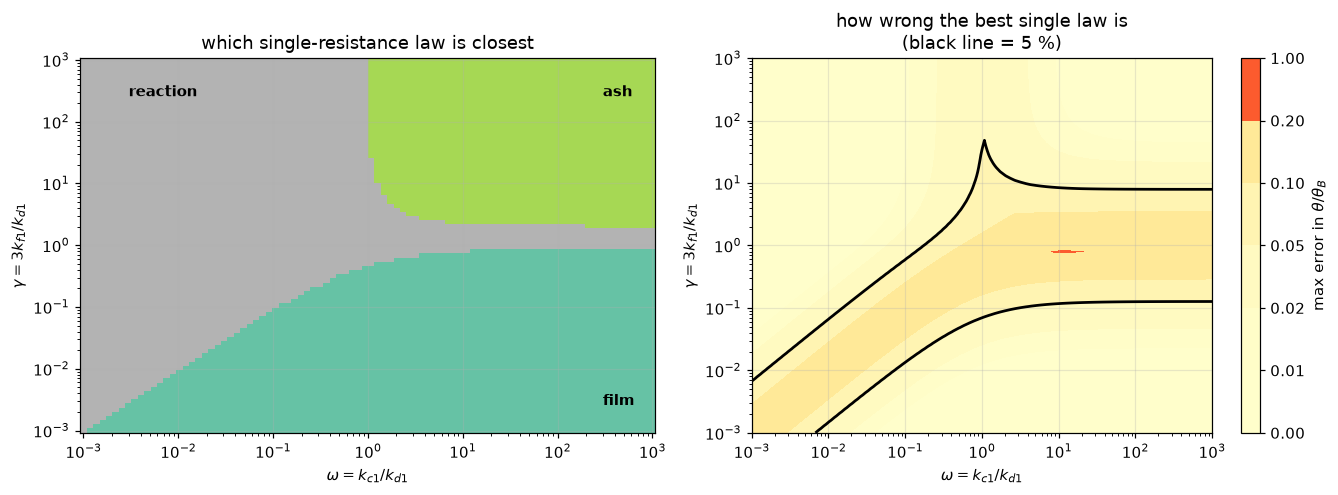

over this six-decade square of (omega, gamma):
   some single-resistance law is within 5 % on 71 % of it,
   within 2 % on 52 %.
   worst case anywhere: 20 % — the middle of the map,
   where no resistance dominates and all three must be kept.
   that worst point is omega = 11.09, gamma = 0.79
Agreement metrics for B3.1:
  eq6_endpoint_x1           = 0
  eq6_vs_integrated_worst   = 6.8695e-16
  eq6_to_film_limit         = 8.2053e-10
  eq6_to_ash_limit          = 2.3473e-08
  eq6_to_reaction_limit     = 3.849e-10
  shell_solve_worst_rel_err = 2.0546e-06
  frac_within_5pct          = 0.7121
  worst_single_law_error    = 0.20309


{'page': 'B3.1',
 'metrics': {'eq6_endpoint_x1': 0.0,
  'eq6_vs_integrated_worst': 6.869504964868156e-16,
  'eq6_to_film_limit': 8.205277568507086e-10,
  'eq6_to_ash_limit': 2.3473231247628235e-08,
  'eq6_to_reaction_limit': 3.84898779515197e-10,
  'shell_solve_worst_rel_err': 2.0545910755899603e-06,
  'frac_within_5pct': 0.7120987654320987,
  'worst_single_law_error': 0.20308587888994767}}

In [6]:
om_g = np.logspace(-3, 3, 90)
ga_g = np.logspace(-3, 3, 90)
best = np.zeros((len(ga_g), len(om_g)), int)
errm = np.zeros_like(best, float)
xs = np.linspace(0.001, 1.0, 300); Xs = 1 - xs**3
names = ["film", "ash", "reaction"]
for i, ga in enumerate(ga_g):
    for j, om in enumerate(om_g):
        full = eq6(xs, om, ga)
        e = [np.abs(full - REGIMES[n](Xs)).max() for n in names]
        best[i, j] = int(np.argmin(e)); errm[i, j] = min(e)

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.6))
ax[0].pcolormesh(om_g, ga_g, best, cmap=plt.get_cmap("Set2", 3), shading="auto")
ax[0].set(xscale="log", yscale="log", xlabel=r"$\omega = k_{c1}/k_{d1}$",
          ylabel=r"$\gamma = 3k_{f1}/k_{d1}$",
          title="which single-resistance law is closest")
for lab, (ox, oy) in (("reaction", (3e-3, 3e2)), ("ash", (3e2, 3e2)),
                      ("film", (3e2, 3e-3))):
    ax[0].text(ox, oy, lab, fontsize=10, fontweight="bold", ha="left", va="center")

cs = ax[1].contourf(om_g, ga_g, errm, levels=[0, 0.01, 0.02, 0.05, 0.10, 0.20, 1.0],
                    cmap="YlOrRd")
ax[1].contour(om_g, ga_g, errm, levels=[0.05], colors="k", linewidths=1.8)
ax[1].set(xscale="log", yscale="log", xlabel=r"$\omega = k_{c1}/k_{d1}$",
          ylabel=r"$\gamma = 3k_{f1}/k_{d1}$",
          title="how wrong the best single law is\n(black line = 5 %)")
fig.colorbar(cs, ax=ax[1], label=r"max error in $\theta/\theta_B$")
fig.tight_layout(); plt.show()

frac5 = (errm <= 0.05).mean()
frac2 = (errm <= 0.02).mean()
print(f"over this six-decade square of (omega, gamma):")
print(f"   some single-resistance law is within 5 % on {100*frac5:.0f} % of it,")
print(f"   within 2 % on {100*frac2:.0f} %.")
print(f"   worst case anywhere: {errm.max()*100:.0f} % — the middle of the map,")
print(f"   where no resistance dominates and all three must be kept.")
i, j = np.unravel_index(errm.argmax(), errm.shape)
print(f"   that worst point is omega = {om_g[j]:.2f}, gamma = {ga_g[i]:.2f}")

report_agreement("B3.1", {
    "eq6_endpoint_x1": float(abs(eq6(1.0, 0.3, 2.0))),
    "eq6_vs_integrated_worst": float(worst),
    "eq6_to_film_limit": float(np.abs(eq6(x,1.0,1e-9)-REGIMES["film"](X)).max()),
    "eq6_to_ash_limit": float(np.abs(eq6(x,BIG,3*BIG)-REGIMES["ash"](X)).max()),
    "eq6_to_reaction_limit": float(np.abs(eq6(x,1e-9,1.0)-REGIMES["reaction"](X)).max()),
    "shell_solve_worst_rel_err": float(max(errs)),
    "frac_within_5pct": float(frac5),
    "worst_single_law_error": float(errm.max()),
})

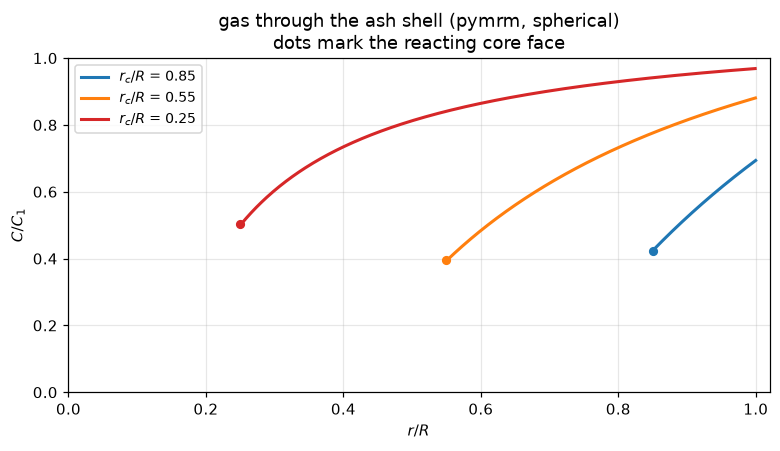

As the core shrinks the shell thickens, the profile steepens, and the
ash resistance grows without bound — which is why ash control gives a
conversion curve that flattens rather than a straight line.


In [7]:
# the profile the whole model is built on, for three shell thicknesses
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for xf, col in ((0.85, "tab:blue"), (0.55, "tab:orange"), (0.25, "tab:red")):
    r, C = shell_profile(xf*R_p, R_p, D_g, 1e-2, 1e-2)
    ax.plot(r/R_p, C, lw=2, color=col, label=f"$r_c/R$ = {xf}")
    ax.plot([xf], [C[0]], "o", ms=5, color=col)
ax.set(xlabel="$r/R$", ylabel="$C/C_1$", xlim=(0, 1.02), ylim=(0, 1),
       title="gas through the ash shell (pymrm, spherical)\n"
             "dots mark the reacting core face")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()
print("As the core shrinks the shell thickens, the profile steepens, and the")
print("ash resistance grows without bound — which is why ash control gives a")
print("conversion curve that flattens rather than a straight line.")

**What this page does not establish.** No experimental
comparison, by construction: the source paper's measurements are of a different
model, and inventing agreement would be worse than admitting there is none. The
regime map is a statement about Eq. 6, not about any real particle — mapping a
given particle onto it requires $k_{c1}$, which cannot be recovered from the
paper as printed. Constant particle size is assumed throughout; a solid that
sheds its ash is a different problem with a different exponent. And the
quasi-steady assumption behind both Eq. 6 and the shell solve is not tested here
— it is excellent for gas–solid systems because the gas holdup in the shell is
smaller than the solid inventory by the molar density ratio, typically $10^{-3}$
or less, but that is an argument rather than a measurement.

## Reuse

**`eq6(x, omega, gamma)` is the whole model** and needs nothing else — two
dimensionless groups in, conversion history out. For a particle whose
coefficients you know, `groups(kc, kf, D, R)` converts them, using the paper's own
$k_{d1} = 12\mathbb{D}_{vs}/D_p$.

**`shell_profile` is the reusable pymrm piece.** A spherical shell with a Robin
condition at each face is the geometry of every ash-layer, product-layer or
shell-progressive problem, and it extends directly: make $\mathbb{D}$ a function
of radius for a sintering ash layer, or add a source term for a solid that also
reacts internally.

**The sign trap, which is the same one as `H1.7`.** Both boundary conditions use
the **outward** normal. At the core face that normal points toward the centre, so
the reacting condition reads $\mathbb{D}\,\partial C/\partial n + k_c C = 0$ with
$d = 0$ — structurally identical to the film condition, not opposite to it. Write
it with the inward normal and the core will appear to emit gas.

**Reading this paper.** The scan's text layer is not usable for equations: it
gives $\theta_B$ as `0B`, drops the exponents in Eq. 6's numerator, and turns
Table 1's velocity range into `0.00 1-0.249`. Render at 600 dpi. Table 2 and
Table 3 transcribe cleanly if you need the elutriation data.

**Related pages.** `B3.2`, `B3.3` (other gas–solid conversion models), `I1.8`,
[`B1.1`](../B1.1-thiele-weisz-hicks/) (the porous-particle counterpart, where the
reaction is distributed rather than at a front).

**Cite the source, not this page:** Yagi, S. and Kunii, D., *Studies on combustion
of carbon particles in flames and fluidized beds*, 5th Symposium (International)
on Combustion, 231–244 (1955).